In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import kagglehub

path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print("Downloaded to:", path)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Downloaded to: /kaggle/input/gtsrb-german-traffic-sign


In [ ]:
TRAIN_DIR   = '/kaggle/input/gtsrb-german-traffic-sign/Train'

TEST_DIR    = '/kaggle/input/gtsrb-german-traffic-sign/Test'
TEST_CSV    = '/kaggle/input/gtsrb-german-traffic-sign/Test.csv'

CLASS_NAMES = {
    0:'Speed limit (20)',    1:'Speed limit (30)',   2:'Speed limit (50)',
    3:'Speed limit (60)',    4:'Speed limit (70)',   5:'Speed limit (80)',
    6:'End speed limit(80)', 7:'Speed limit (100)',  8:'Speed limit (120)',
    9:'No passing',         10:'No passing >3.5t',  11:'Right-of-way',
    12:'Priority road',     13:'Yield',              14:'Stop',
    15:'No vehicles',       16:'No >3.5t vehicles', 17:'No entry',
    18:'General caution',   19:'Danger curve left', 20:'Danger curve right',
    21:'Double curve',      22:'Bumpy road',         23:'Slippery road',
    24:'Road narrows',      25:'Road work',          26:'Traffic signals',
    27:'Pedestrians',       28:'Children crossing',  29:'Bicycles crossing',
    30:'Ice/snow',          31:'Wild animals',       32:'End speed+passing',
    33:'Turn right ahead',  34:'Turn left ahead',    35:'Ahead only',
    36:'Go straight/right', 37:'Go straight/left',   38:'Keep right',
    39:'Keep left',         40:'Roundabout',          41:'End no passing',
    42:'End no passing >3.5t'
}

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [ ]:
data_list = []
labels_list = []
classes_list = 43
for i in range(classes_list):
    i_path = os.path.join(TRAIN_DIR, str(i)) #0-42
    for img in os.listdir(i_path):
        im = Image.open(i_path +'/'+ img)
        im = im.resize((32,32))
        im = np.array(im)
        data_list.append(im)
        labels_list.append(i)
data = np.array(data_list)
labels = np.array(labels_list)

In [ ]:
test_data_list = []
test_labels_list = []

test_csv_df = pd.read_csv(TEST_CSV)
test_filenames = test_csv_df['Path'].tolist()
test_class_ids = test_csv_df['ClassId'].tolist()


for idx, filename in enumerate(test_filenames):
    # Đường dẫn đầy đủ đến ảnh test
    filename = filename.replace('Test/', '')
    img_path = os.path.join(TEST_DIR, filename)
    im = Image.open(img_path)
    im = im.resize((32,32))
    im = np.array(im)
    test_data_list.append(im)
    test_labels_list.append(test_class_ids[idx])

test_data = np.array(test_data_list)
test_labels = np.array(test_labels_list)

print(f"Shape của test_data: {test_data.shape}")
print(f"Shape của test_labels: {test_labels.shape}")

Shape của test_data: (12630, 32, 32, 3)
Shape của test_labels: (12630,)


In [ ]:
np.save('/content/data.npy', data)
np.save('/content/labels.npy', labels)

In [ ]:
!cp /content/data.npy /content/drive/MyDrive/gtsrb_dataset/
!cp /content/labels.npy /content/drive/MyDrive/gtsrb_dataset/

In [ ]:
np.save('/content/test_data.npy', test_data)
np.save('/content/test_labels.npy', test_labels)

In [ ]:
!cp /content/test_data.npy /content/drive/MyDrive/gtsrb_dataset/
!cp /content/test_labels.npy /content/drive/MyDrive/gtsrb_dataset/

In [ ]:
import numpy as np

data = np.load('/content/drive/MyDrive/gtsrb_dataset/data.npy')
labels = np.load('/content/drive/MyDrive/gtsrb_dataset/labels.npy')

In [ ]:
import numpy as np

test_data = np.load('/content/drive/MyDrive/gtsrb_dataset/test_data.npy')
test_labels = np.load('/content/drive/MyDrive/gtsrb_dataset/test_labels.npy')

In [ ]:
print(f"Shape của data: {data.shape}")
print(f"Shape của labels: {labels.shape}")

Shape của data: (39209, 32, 32, 3)
Shape của labels: (39209,)


In [ ]:
print(f"Shape của test: {test_data.shape}")
print(f"Shape của test labels: {test_labels.shape}")

array([[[255, 253, 213],
        [255, 253, 214],
        [255, 251, 215],
        ...,
        [237, 221, 185],
        [235, 219, 184],
        [234, 216, 182]],

       [[255, 255, 229],
        [255, 255, 228],
        [255, 255, 229],
        ...,
        [253, 240, 204],
        [253, 239, 201],
        [253, 238, 201]],

       [[255, 255, 239],
        [255, 255, 237],
        [255, 255, 234],
        ...,
        [255, 246, 205],
        [254, 246, 207],
        [254, 244, 209]],

       ...,

       [[255, 255, 229],
        [255, 255, 226],
        [255, 255, 222],
        ...,
        [183, 172, 142],
        [182, 169, 138],
        [181, 168, 138]],

       [[255, 255, 229],
        [255, 255, 224],
        [255, 255, 222],
        ...,
        [195, 183, 151],
        [192, 180, 150],
        [192, 180, 148]],

       [[255, 255, 227],
        [255, 255, 226],
        [255, 255, 224],
        ...,
        [203, 191, 157],
        [202, 190, 157],
        [201, 187, 155]]], dtype=uint8)
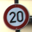

In [ ]:
data[0]

In [ ]:
labels

array([ 0,  0,  0, ..., 42, 42, 42])

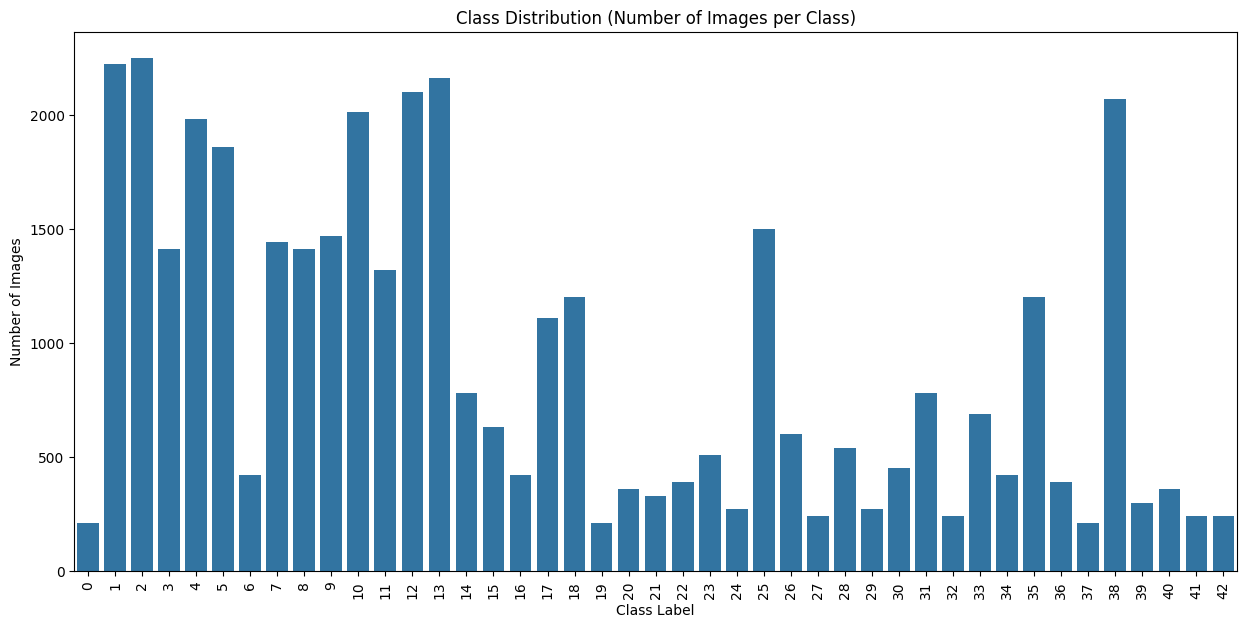

In [ ]:
plt.figure(figsize=(15, 7))
sns.countplot(x=labels)
plt.title('Class Distribution (Number of Images per Class)')
plt.xlabel('Class Label')
plt.ylabel('Number of Images')
plt.xticks(rotation=90)
plt.show()

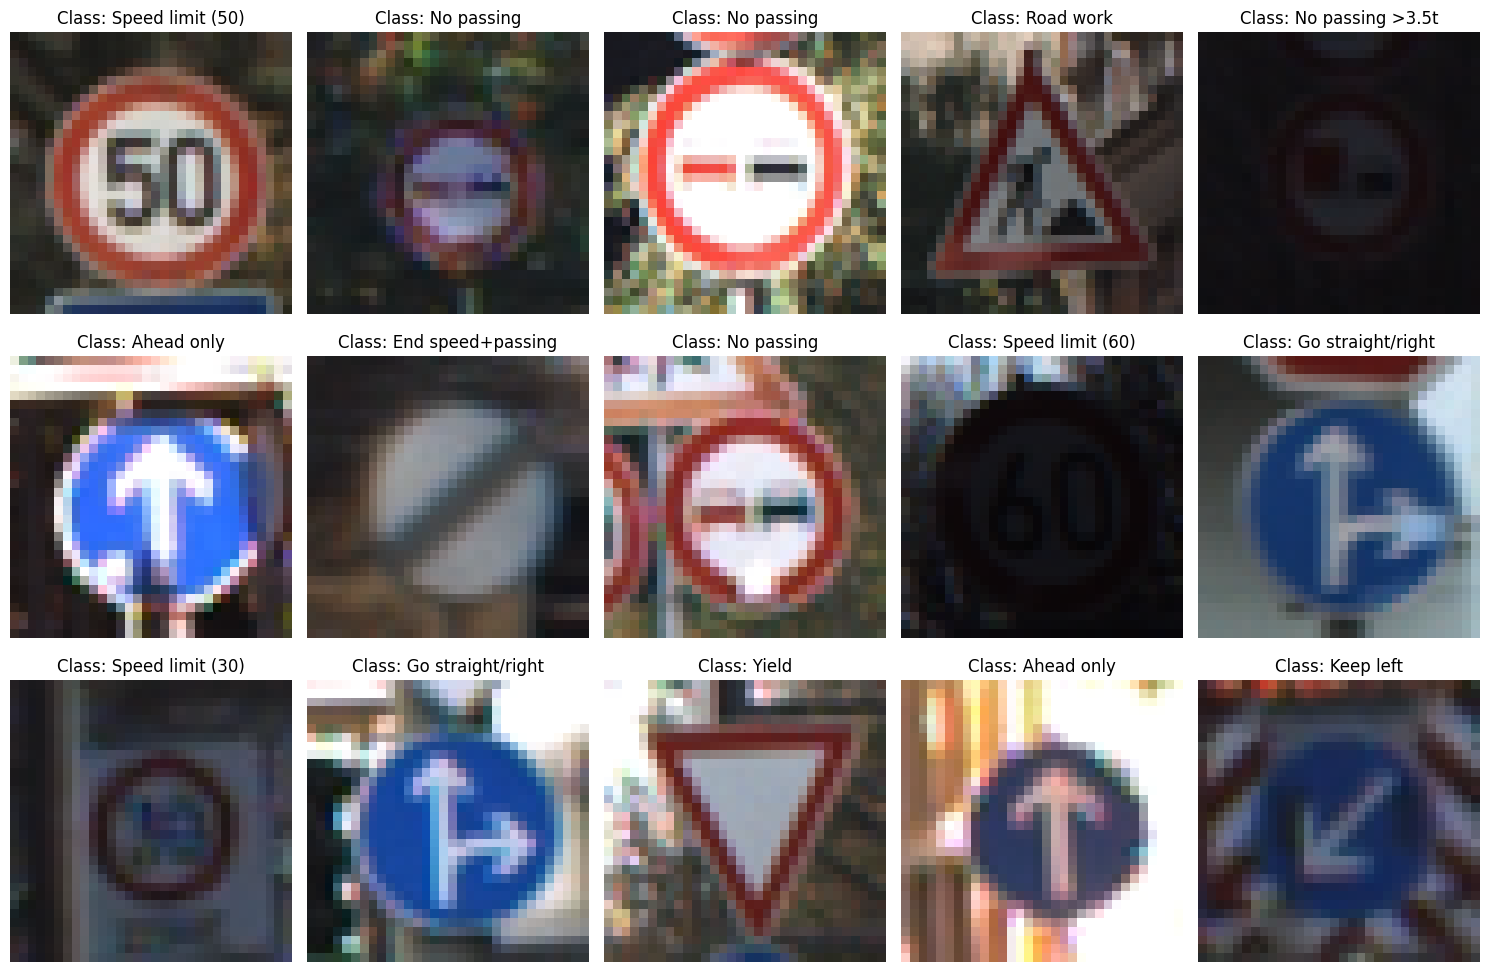

In [ ]:
import random

num_samples = 15

plt.figure(figsize=(15, 10))

for i in range(num_samples):
    index = random.randint(0, len(data) - 1)
    plt.subplot(3, 5, i + 1)
    plt.imshow(data[index])
    plt.title(f"Class: {CLASS_NAMES[labels[index]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
X_train_raw = data
y_train = labels
X_test_raw = test_data
y_test = test_labels


Trích xuất đặc trưng HOG là một kỹ thuật phổ biến trong Machine Learning truyền thống để mô tả hình dạng cục bộ và cấu trúc của đối tượng trong ảnh. Nó hoạt động bằng cách tính toán hướng của gradient và xây dựng biểu đồ histogram các hướng đó trong các vùng nhỏ (cells) của ảnh.

Trong bước này, chúng ta sẽ viết một hàm để thực hiện việc này và áp dụng nó cho cả tập huấn luyện và kiểm tra.

In [ ]:
import numpy as np
import cv2
from skimage.feature import hog
from tqdm import tqdm

def extract_hybrid_features(images):
    """
    Hàm trích xuất đặc trưng lai ghép (HOG + HSV Color Histogram)
    có tích hợp tiền xử lý ánh sáng CLAHE.

    Input: images - mảng numpy chứa các ảnh RGB kích thước (N, 32, 32, 3)
    Output: mảng numpy chứa vector đặc trưng lai ghép kích thước (N, d)
    """
    features_list = []

    # Khởi tạo bộ lọc CLAHE (Contrast Limited Adaptive Histogram Equalization)
    # clipLimit kiểm soát đạo hàm của hàm phân phối, tránh khuếch đại nhiễu
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))

    # Bọc vòng lặp bằng tqdm để hiện thanh tiến trình
    for img in tqdm(images, desc="Trích xuất Đặc trưng Lai ghép (HOG + HSV)"):

        # ==========================================
        # BƯỚC 1: TIỀN XỬ LÝ & TRÍCH XUẤT HOG (HÌNH HỌC)
        # ==========================================
        # Chuyển ảnh RGB sang xám
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        # Cân bằng ánh sáng cục bộ bằng CLAHE
        gray_clahe = clahe.apply(gray)

        # Trích xuất Fine-grained HOG (lưới 4x4 thay vì 8x8)
        hog_features = hog(gray_clahe,
                           orientations=9,
                           pixels_per_cell=(4, 4),
                           cells_per_block=(2, 2),
                           block_norm='L2-Hys', # Chuẩn hóa L2 có cắt xén
                           visualize=False,
                           feature_vector=True)

        # ==========================================
        # BƯỚC 2: TRÍCH XUẤT COLOR HISTOGRAM (MÀU SẮC)
        # ==========================================
        # Chuyển ảnh RGB sang không gian màu HSV
        hsv_img = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

        # Tính Histogram cho từng kênh H (Hue), S (Saturation), V (Value)
        # Dùng 16 bins cho mỗi kênh để nén thông tin, không làm vector quá lớn
        hist_h = cv2.calcHist([hsv_img], [0], None, [16], [0, 180])
        hist_s = cv2.calcHist([hsv_img], [1], None, [16], [0, 256])
        hist_v = cv2.calcHist([hsv_img], [2], None, [16], [0, 256])

        # Chuẩn hóa L2 Norm cho từng Histogram để đồng nhất thang đo với HOG
        cv2.normalize(hist_h, hist_h, norm_type=cv2.NORM_L2)
        cv2.normalize(hist_s, hist_s, norm_type=cv2.NORM_L2)
        cv2.normalize(hist_v, hist_v, norm_type=cv2.NORM_L2)

        # Duỗi thẳng và nối 3 histogram lại thành 1 vector màu (16 + 16 + 16 = 48 chiều)
        color_features = np.concatenate((hist_h.flatten(), hist_s.flatten(), hist_v.flatten()))

        # ==========================================
        # BƯỚC 3: DUNG HỢP ĐẶC TRƯNG (FEATURE FUSION)
        # ==========================================
        # Nối vector Hình học (HOG) và vector Màu sắc (HSV)
        hybrid_features = np.concatenate((hog_features, color_features))

        features_list.append(hybrid_features)

    return np.array(features_list)

# Cách gọi hàm (Em thay đoạn code cũ bằng 2 dòng này):
X_train_hog = extract_hybrid_features(X_train_raw)
X_test_hog = extract_hybrid_features(X_test_raw)

Trích xuất Đặc trưng Lai ghép (HOG + HSV): 100%|██████████| 12630/12630 [00:25<00:00, 500.30it/s]


In [ ]:
print(f"Shape của train hog+hsv: {X_train_hog.shape}")
print(f"Shape của test hog+hsv: {X_test_hog.shape}")

Shape của train hog+hsv: (39209, 1812)
Shape của test hog+hsv: (12630, 1812)


In [ ]:
X_train_hog[0]

array([0.06449156, 0.        , 0.        , ..., 0.22870338, 0.04111521,
       0.81459516])

In [ ]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_hog)
X_test_scaled = scaler.transform(X_test_hog)

# In ra giá trị mean và variance của một vài đặc trưng ngẫu nhiên trong X_train_scaled để xác nhận.
num_features_to_check = 5
random_feature_indices = np.random.choice(X_train_scaled.shape[1], num_features_to_check, replace=False)

for i, idx in enumerate(random_feature_indices):
    feature_mean = np.mean(X_train_scaled[:, idx])
    feature_variance = np.var(X_train_scaled[:, idx])
    print(f"Đặc trưng ngẫu nhiên {i+1} (chỉ số {idx}): Mean = {feature_mean:.4f}, Variance = {feature_variance:.4f}")

print(f"\nShape của X_train_scaled: {X_train_scaled.shape}")
print(f"Shape của X_test_scaled: {X_test_scaled.shape}")

Đặc trưng ngẫu nhiên 1 (chỉ số 432): Mean = 0.0000, Variance = 1.0000
Đặc trưng ngẫu nhiên 2 (chỉ số 1434): Mean = -0.0000, Variance = 1.0000
Đặc trưng ngẫu nhiên 3 (chỉ số 323): Mean = 0.0000, Variance = 1.0000
Đặc trưng ngẫu nhiên 4 (chỉ số 912): Mean = -0.0000, Variance = 1.0000
Đặc trưng ngẫu nhiên 5 (chỉ số 920): Mean = -0.0000, Variance = 1.0000

Shape của X_train_scaled: (39209, 1812)
Shape của X_test_scaled: (12630, 1812)


In [ ]:
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

print("Bước 1: Lấy mẫu phụ (Subsampling) để Tuning...")
# Tính toán 10% số lượng mẫu từ X_train_scaled
num_samples_tune = int(X_train_scaled.shape[0] * 0.1)

# Trích xuất ngẫu nhiên khoảng 10% dữ liệu từ X_train_scaled và y_train
X_tune, _, y_tune, _ = train_test_split(
    X_train_scaled, y_train, train_size=num_samples_tune, stratify=y_train, random_state=42
)

print(f"  Shape của X_tune: {X_tune.shape}")
print(f"  Shape của y_tune: {y_tune.shape}\n")

print("Tìm kiếm lưới (GridSearchCV) trên tập Subsample...")
start_time_gridsearch = time.time()

# Khởi tạo mô hình SVC
svc_model = SVC(class_weight='balanced', random_state=42)

# Định nghĩa không gian tìm kiếm siêu tham số
param_grid = [
    {'kernel': ['linear'],
     'C': [0.01, 0.1, 1, 10, 100]
     },
    {'kernel': ['rbf'],
     'C': [0.01, 0.1, 1, 10, 100],
     'gamma': ['scale', 'auto', 0.1, 0.01, 0.001, 0.0001]},
    {'kernel': ['poly'],
     'C': [0.01, 0.1, 1, 10, 100],
     'degree': [2, 3, 4],
     'gamma': ['scale', 'auto', 0.1, 0.01, 0.001, 0.0001]},
    {'kernel': ['sigmoid'],
     'C': [0.01, 0.1, 1, 10, 100],
     'gamma': ['scale', 'auto', 0.1, 0.01, 0.001, 0.0001]}
]

# Khởi tạo GridSearchCV
grid_search = GridSearchCV(
    estimator=svc_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Tiến hành .fit() trên tập (X_tune, y_tune)
grid_search.fit(X_tune, y_tune)

print("Kết thúc GridSearchCV. Bộ tham số tốt nhất là:", grid_search.best_params_)

# Tạo pandas DataFrame từ grid.cv_results_
results_df = pd.DataFrame(grid_search.cv_results_)

# Chỉ lấy các cột được yêu cầu
columns_to_display = [
    'param_kernel', 'param_C', 'param_gamma', 'param_degree',
    'mean_test_score', 'std_test_score', 'mean_fit_time'
]

# Kiểm tra và thêm các cột nếu chúng tồn tại (gamma, degree chỉ có với một số kernel)
actual_columns = [col for col in columns_to_display if col in results_df.columns]
filtered_results_df = results_df[actual_columns]

# Sắp xếp bảng theo mean_test_score giảm dần
filtered_results_df = filtered_results_df.sort_values(by='mean_test_score', ascending=False)

print("Top 10 cấu hình tốt nhất:")
display(filtered_results_df.head(10))

end_time_gridsearch = time.time()

print(f"  Thời gian chạy GridSearchCV: {end_time_gridsearch - start_time_gridsearch:.2f} giây\n")



Bước 1: Lấy mẫu phụ (Subsampling) để Tuning...
  Shape của X_tune: (3920, 1812)
  Shape của y_tune: (3920,)

Tìm kiếm lưới (GridSearchCV) trên tập Subsample...
Fitting 3 folds for each of 155 candidates, totalling 465 fits
Kết thúc GridSearchCV. Bộ tham số tốt nhất là: {'C': 100, 'gamma': 0.0001, 'kernel': 'rbf'}
Top 10 cấu hình tốt nhất:


,param_kernel,param_C,param_gamma,param_degree,mean_test_score,std_test_score,mean_fit_time
34,rbf,100.00,0.0001,NaN,0.915817,0.003287,13.106646
1,linear,0.10,NaN,NaN,0.914797,0.004362,15.661061
0,linear,0.01,NaN,NaN,0.914797,0.004362,29.136557
3,linear,10.00,NaN,NaN,0.914797,0.004362,11.669479
4,linear,100.00,NaN,NaN,0.914797,0.004362,12.400407
2,linear,1.00,NaN,NaN,0.914797,0.004362,13.154712
154,sigmoid,100.00,0.0001,NaN,0.914032,0.004664,10.222977
28,rbf,10.00,0.0001,NaN,0.914031,0.004845,13.440077
148,sigmoid,10.00,0.0001,NaN,0.910970,0.003415,11.738152
137,sigmoid,1.00,scale,NaN,0.906379,0.003521,11.171137


  Thời gian chạy GridSearchCV: 7971.61 giây



In [ ]:
display(filtered_results_df)

,param_kernel,param_C,param_gamma,param_degree,mean_test_score,std_test_score,mean_fit_time
34,rbf,100.00,0.0001,NaN,0.915817,0.003287,13.106646
1,linear,0.10,NaN,NaN,0.914797,0.004362,15.661061
0,linear,0.01,NaN,NaN,0.914797,0.004362,29.136557
3,linear,10.00,NaN,NaN,0.914797,0.004362,11.669479
4,linear,100.00,NaN,NaN,0.914797,0.004362,12.400407
...,...,...,...,...,...,...,...
14,rbf,0.10,0.01,NaN,0.028323,0.017332,26.246545
70,poly,0.10,0.0001,4.0,0.028323,0.017332,27.167282
136,sigmoid,0.10,0.0001,NaN,0.027042,0.005092,27.832719
8,rbf,0.01,0.01,NaN,0.020667,0.010833,26.081429


In [ ]:
print("Huấn luyện mô hình cuối cùng (Final Model Training)...")
start_time_final_training = time.time()

# Khởi tạo lại một mô hình SVC mới với bộ tham số tốt nhất
final_svm_model = SVC(class_weight='balanced', random_state=42, **grid_search.best_params_)

# Tiến hành .fit() mô hình này trên toàn bộ tập dữ liệu huấn luyện lớn
final_svm_model.fit(X_train_scaled, y_train)

end_time_final_training = time.time()

print("  Kết thúc huấn luyện mô hình cuối cùng.")
print(f"  Thời gian huấn luyện mô hình cuối cùng: {end_time_final_training - start_time_final_training:.2f} giây")


Huấn luyện mô hình cuối cùng (Final Model Training)...
  Kết thúc huấn luyện mô hình cuối cùng.
  Thời gian huấn luyện mô hình cuối cùng: 472.95 giây


In [ ]:
import joblib

maybe_final_svm_model = joblib.load('/content/drive/MyDrive/gtsrb_dataset/last_model.pkl')

In [ ]:
test_labels[0]

np.int64(16)

array([[[116, 140, 175],
        [116, 137, 172],
        [119, 138, 173],
        ...,
        [100, 118, 146],
        [ 99, 121, 148],
        [ 90, 110, 136]],

       [[116, 142, 177],
        [115, 140, 175],
        [117, 141, 175],
        ...,
        [121, 144, 178],
        [122, 143, 175],
        [122, 142, 173]],

       [[117, 142, 174],
        [117, 141, 175],
        [114, 140, 173],
        ...,
        [120, 144, 180],
        [122, 144, 179],
        [120, 143, 178]],

       ...,

       [[117, 137, 168],
        [116, 135, 165],
        [117, 134, 164],
        ...,
        [115, 137, 169],
        [116, 136, 168],
        [118, 138, 171]],

       [[116, 136, 166],
        [114, 134, 167],
        [114, 132, 166],
        ...,
        [114, 135, 168],
        [117, 136, 166],
        [115, 139, 167]],

       [[112, 135, 167],
        [111, 134, 165],
        [118, 135, 165],
        ...,
        [115, 138, 166],
        [117, 138, 167],
        [114, 140, 170]]], dtype=uint8)
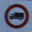

In [ ]:
test_data[0]

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

# --- Dự đoán và Tính toán các chỉ số tổng quan ---
print("\n--- Bước 1: Dự đoán và Tính toán các chỉ số tổng quan ---")
y_pred = final_svm_model.predict(X_test_scaled)

# In Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}\n")

# In Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]))



--- Bước 1: Dự đoán và Tính toán các chỉ số tổng quan ---
Accuracy Score: 0.9169

Classification Report:
                      precision    recall  f1-score   support

    Speed limit (20)       0.95      0.58      0.72        60
    Speed limit (30)       0.87      0.88      0.88       720
    Speed limit (50)       0.81      0.86      0.84       750
    Speed limit (60)       0.84      0.78      0.81       450
    Speed limit (70)       0.96      0.95      0.95       660
    Speed limit (80)       0.76      0.84      0.80       630
 End speed limit(80)       0.91      0.77      0.83       150
   Speed limit (100)       0.93      0.91      0.92       450
   Speed limit (120)       0.88      0.89      0.89       450
          No passing       0.96      0.99      0.98       480
    No passing >3.5t       0.99      0.99      0.99       660
        Right-of-way       0.87      0.92      0.89       420
       Priority road       1.00      1.00      1.00       690
               Yield     


--- Bước 2: Vẽ Ma trận nhầm lẫn (Confusion Matrix) trực quan ---


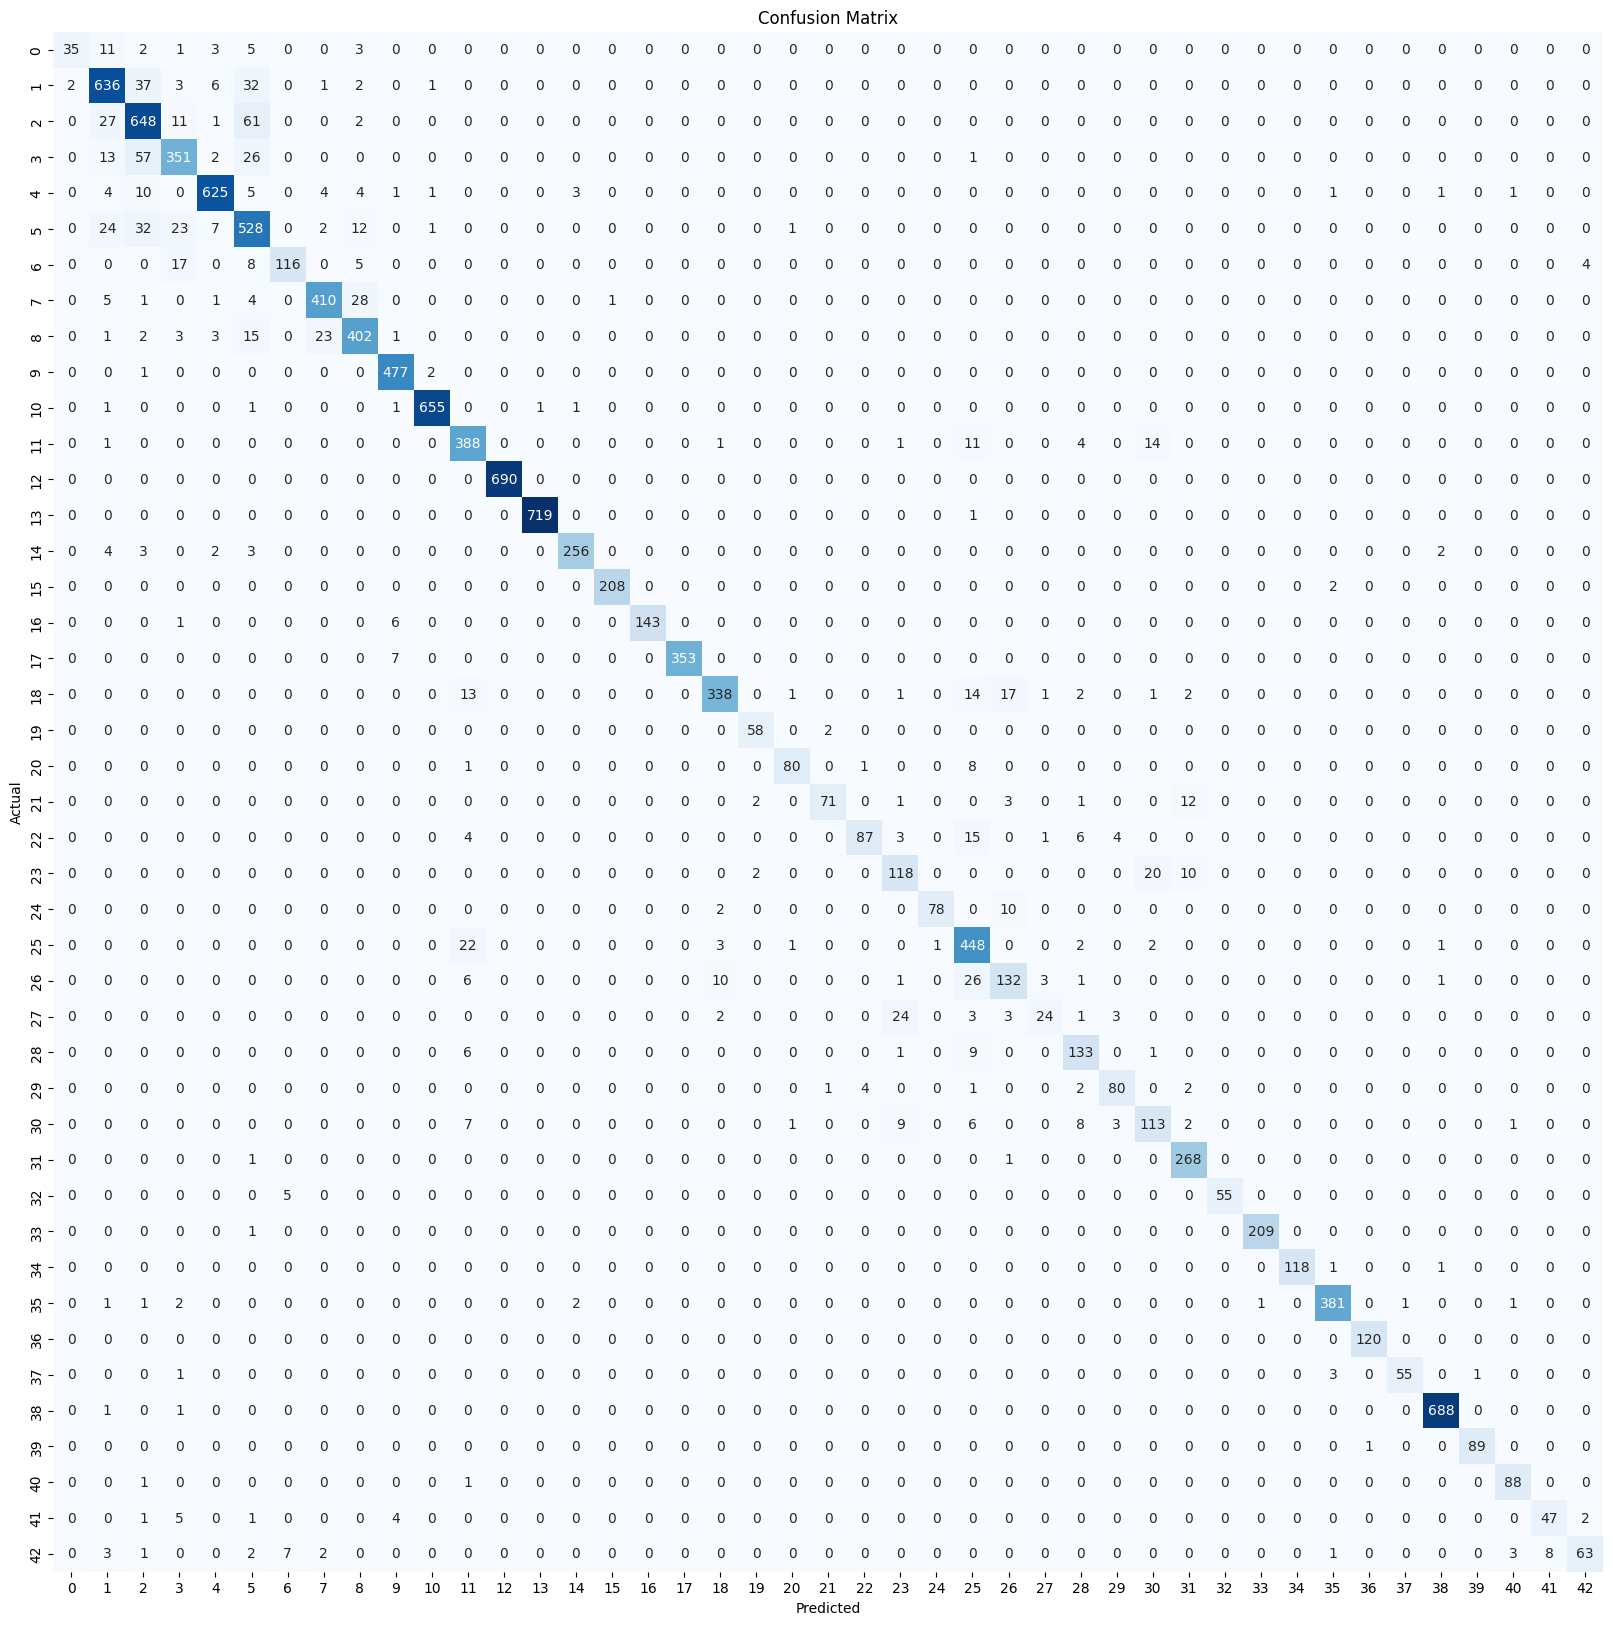

In [ ]:
# --- Vẽ Ma trận nhầm lẫn (Confusion Matrix) trực quan ---
print("\n--- Bước 2: Vẽ Ma trận nhầm lẫn (Confusion Matrix) trực quan ---")
cm = confusion_matrix(y_test, y_pred)


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


--- Bước 3: Phân tích Lỗi (Error Analysis) - Trực quan hóa hình ảnh bị sai ---


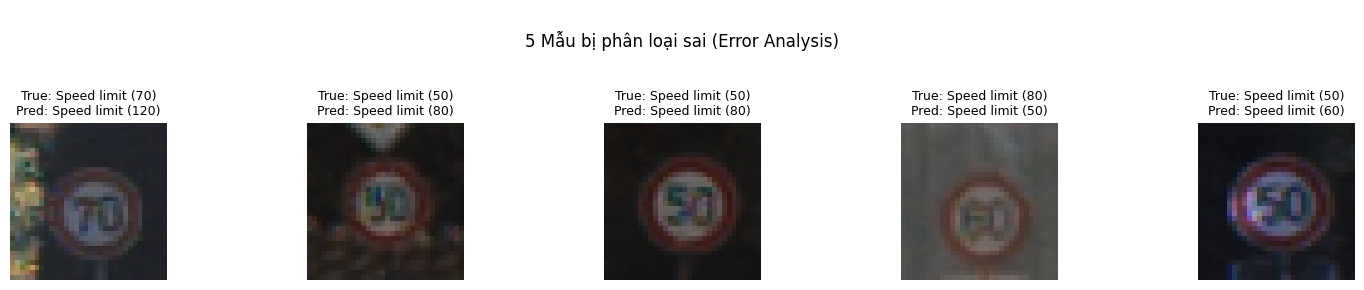

In [ ]:
# --- Phân tích Lỗi (Error Analysis) - Trực quan hóa hình ảnh bị sai ---
print("\n--- Bước 3: Phân tích Lỗi (Error Analysis) - Trực quan hóa hình ảnh bị sai ---")

# Tìm các chỉ số của các mẫu bị phân loại sai
misclassified_indices = np.where(y_pred != y_test)[0]

if len(misclassified_indices) == 0:
    print("Không có mẫu nào bị phân loại sai.")
else:
    # Lấy ngẫu nhiên 5 mẫu bị phân loại sai
    num_samples_to_show = min(5, len(misclassified_indices))
    random_misclassified_samples = random.sample(list(misclassified_indices), num_samples_to_show)

    plt.figure(figsize=(15, 3))
    for i, index in enumerate(random_misclassified_samples):
        plt.subplot(1, num_samples_to_show, i + 1)
        plt.imshow(X_test_raw[index]) # Hiển thị ảnh thô gốc
        true_label = CLASS_NAMES[y_test[index]]
        pred_label = CLASS_NAMES[y_pred[index]]
        plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=9)
        plt.axis('off')

    plt.suptitle(f"\n{num_samples_to_show} Mẫu bị phân loại sai (Error Analysis)", fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()


--- Bước 1: Tính toán và làm rỗng đường chéo chính ---
Đã tạo ma trận lỗi (error_cm) và làm rỗng đường chéo chính.

--- Bước 2: Trích xuất Top 10 cặp nhầm lẫn nhiều nhất ---
Top 10 cặp nhầm lẫn nhiều nhất:


,Nhãn thực tế (True Label),Nhãn dự đoán (Predicted),Tên biển báo thực tế,Tên biển báo dự đoán,Số lần nhầm lẫn
0,2,5,Speed limit (50),Speed limit (80),61
1,3,2,Speed limit (60),Speed limit (50),57
2,1,2,Speed limit (30),Speed limit (50),37
3,1,5,Speed limit (30),Speed limit (80),32
4,5,2,Speed limit (80),Speed limit (50),32
5,7,8,Speed limit (100),Speed limit (120),28
6,2,1,Speed limit (50),Speed limit (30),27
7,3,5,Speed limit (60),Speed limit (80),26
8,26,25,Traffic signals,Road work,26
9,27,23,Pedestrians,Slippery road,24



--- Bước 3: Vẽ biểu đồ ma trận lỗi ---


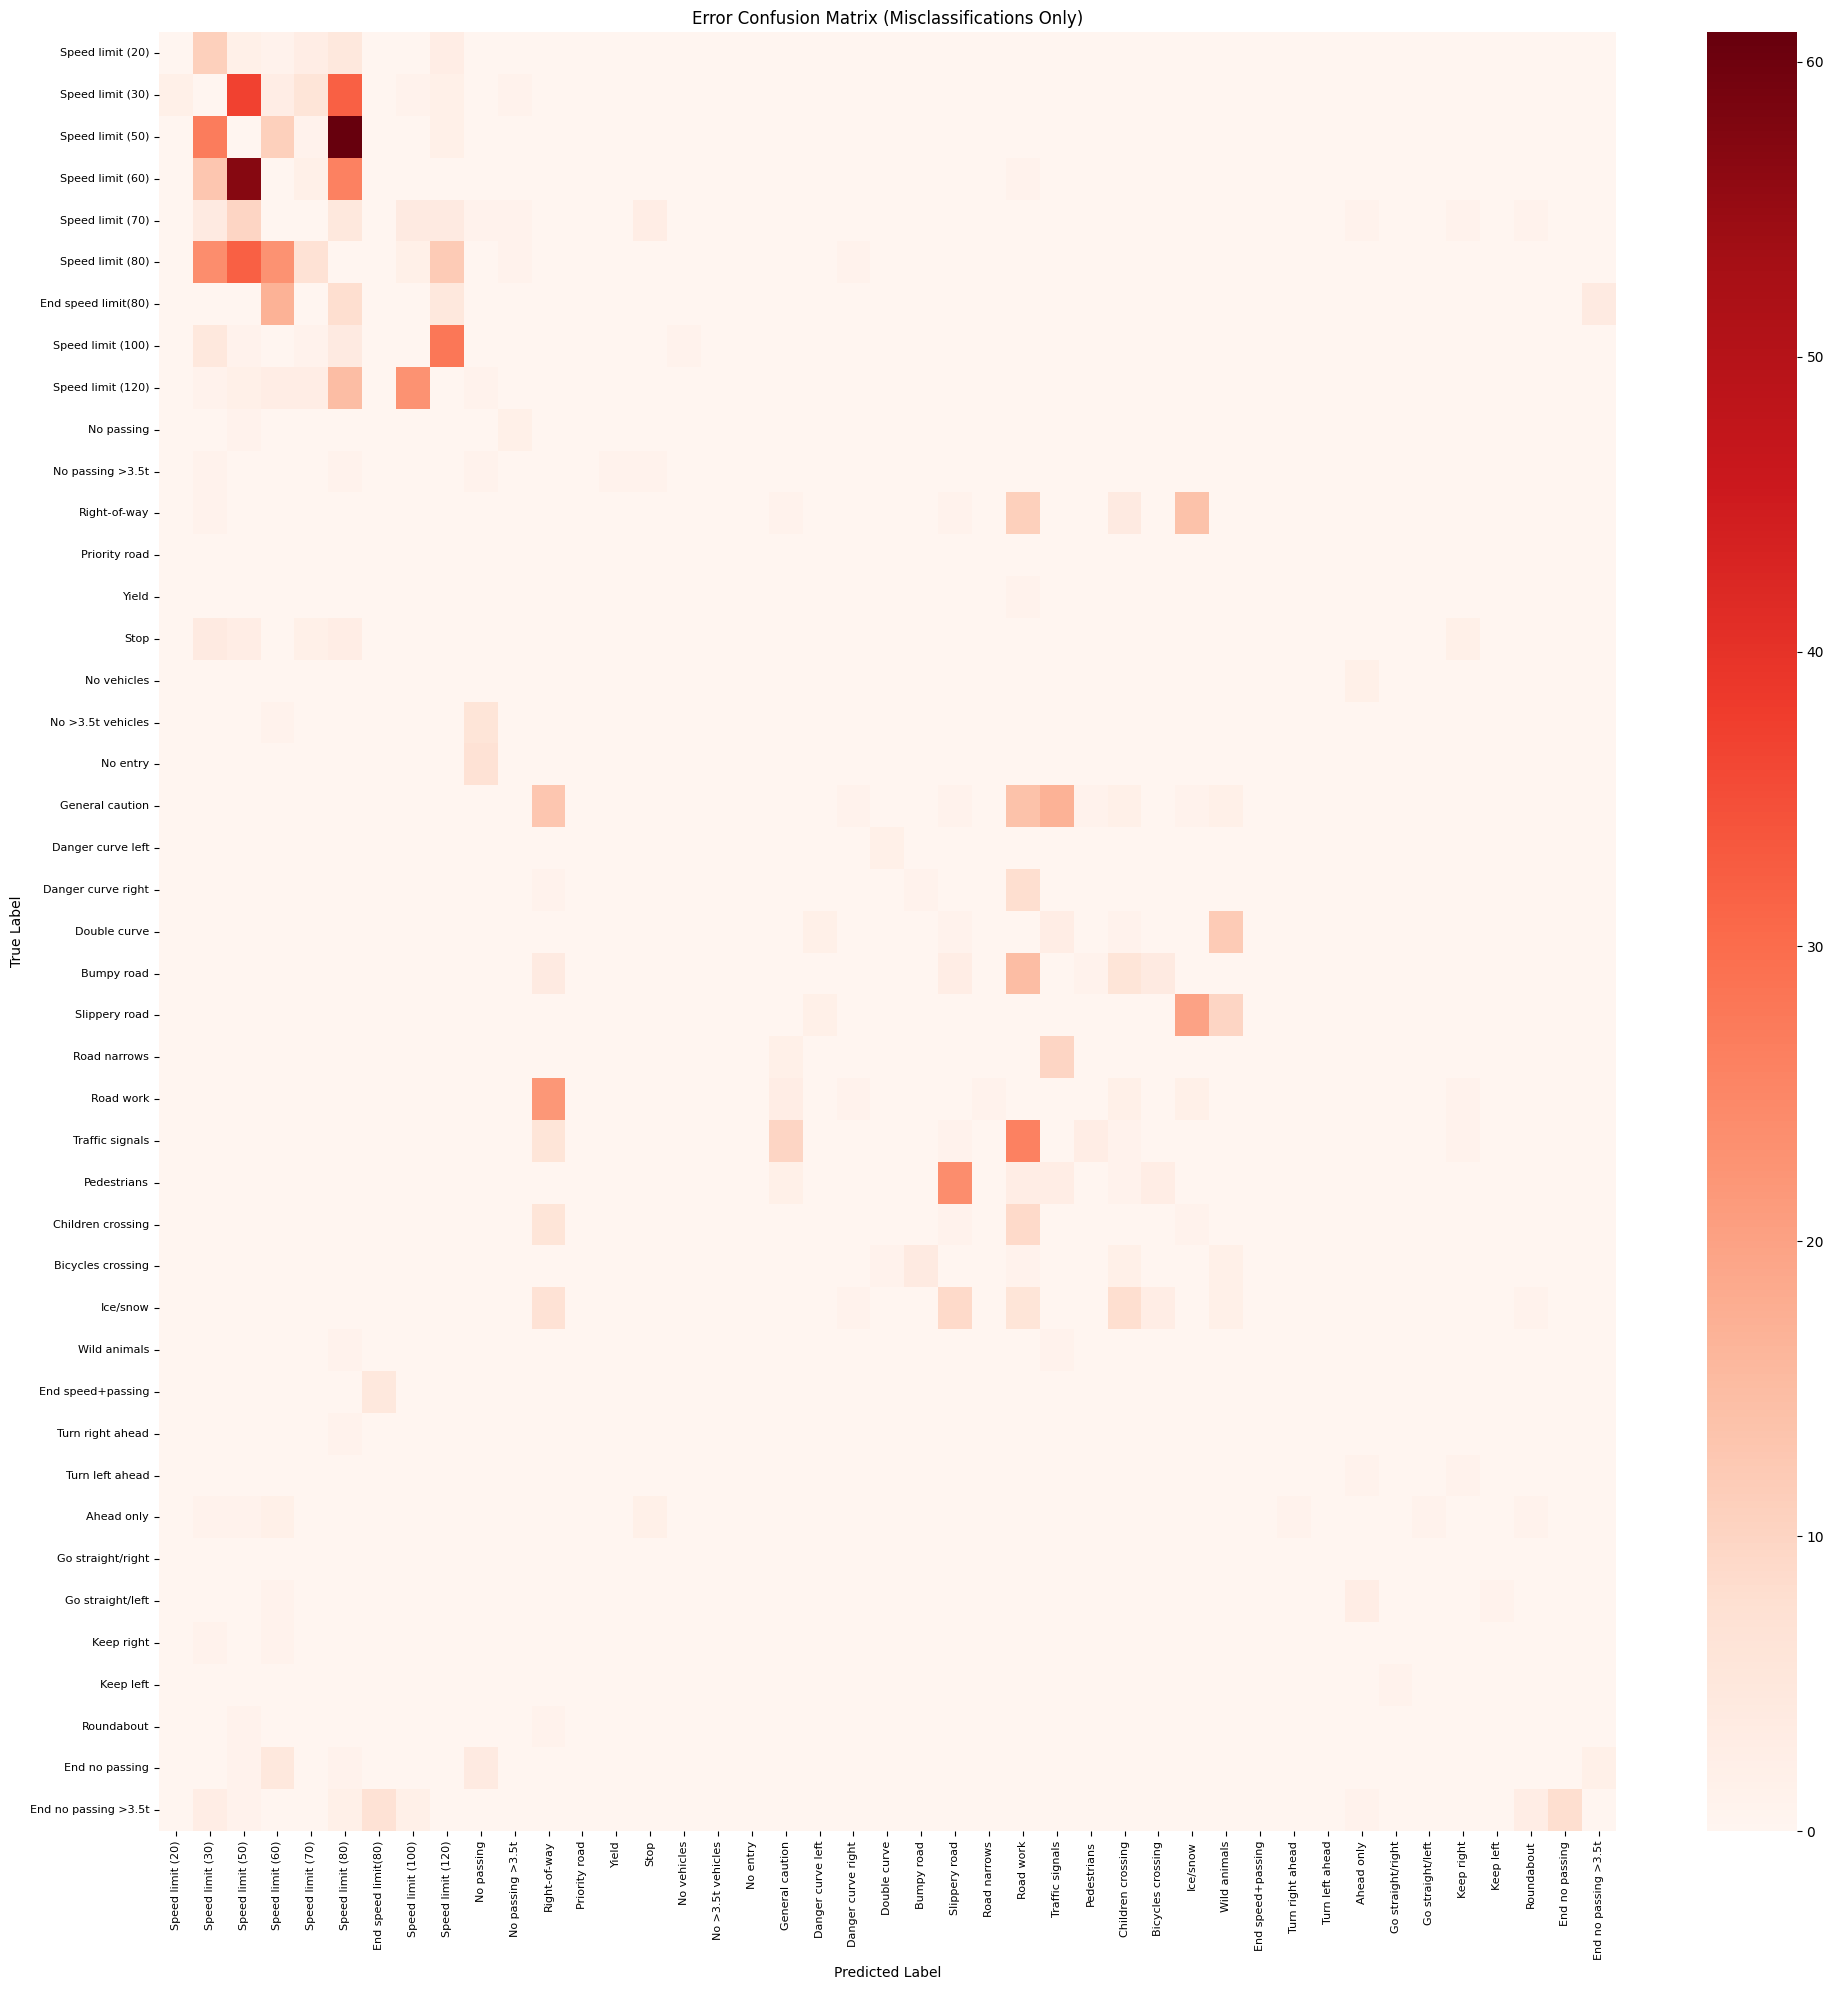

In [ ]:
print("\n--- Bước 1: Tính toán và làm rỗng đường chéo chính ---")
# cm đã được tính ở bước trước
error_cm = cm.copy()
np.fill_diagonal(error_cm, 0) # Gán giá trị trên đường chéo chính bằng 0
print("Đã tạo ma trận lỗi (error_cm) và làm rỗng đường chéo chính.")


print("\n--- Bước 2: Trích xuất Top 10 cặp nhầm lẫn nhiều nhất ---")

# Tìm tọa độ của các giá trị lớn nhất trong error_cm
# Sử dụng np.unravel_index để chuyển chỉ số phẳng thành chỉ số 2D (hàng, cột)
# Lấy 10 chỉ số lớn nhất
flat_indices = np.argsort(error_cm.ravel())[::-1][:10]
row_indices, col_indices = np.unravel_index(flat_indices, error_cm.shape)

# Tạo DataFrame để lưu kết quả
top_misclassifications = pd.DataFrame(columns=[
    'Nhãn thực tế (True Label)',
    'Nhãn dự đoán (Predicted)',
    'Tên biển báo thực tế',
    'Tên biển báo dự đoán',
    'Số lần nhầm lẫn'
])

for i in range(10):
    true_label_idx = row_indices[i]
    pred_label_idx = col_indices[i]
    count = error_cm[true_label_idx, pred_label_idx]

    # Lấy tên biển báo từ CLASS_NAMES
    true_sign_name = CLASS_NAMES[true_label_idx]
    pred_sign_name = CLASS_NAMES[pred_label_idx]

    top_misclassifications.loc[i] = [
        true_label_idx,
        pred_label_idx,
        true_sign_name,
        pred_sign_name,
        count
    ]

print("Top 10 cặp nhầm lẫn nhiều nhất:")
display(top_misclassifications)


print("\n--- Bước 3: Vẽ biểu đồ ma trận lỗi ---")
plt.figure(figsize=(20, 20))
sns.heatmap(error_cm, cmap='Reds', annot=False,
            xticklabels=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())],
            yticklabels=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Error Confusion Matrix (Misclassifications Only)')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

Trích xuất Đặc trưng Lai ghép (HOG + HSV): 100%|██████████| 1/1 [00:00<00:00, 152.20it/s]


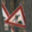

Dự đoán: Right-of-way
Confidence Score: 42.3235


In [ ]:
from PIL import Image


test_image = '00079.png';
img = Image.open(TEST_DIR + '/' + test_image)
img = img.resize((32,32))
img_array = np.array(img)

# Extract HOG features for the single image
img_hog = extract_hybrid_features(np.array([img_array]))

# Scale the HOG features using the fitted scaler
img_scaled = scaler.transform(img_hog)

pred_label_idx = maybe_final_svm_model.predict(img_scaled)[0]

decision_scores = maybe_final_svm_model.decision_function(img_scaled)[0]
confidence_score = decision_scores[pred_label_idx]


img.thumbnail((150, 150))
display(img)

print(f"Dự đoán: {CLASS_NAMES[pred_label_idx]}")
print(f"Confidence Score: {confidence_score:.4f}")

In [ ]:
import time
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

print("\n--- Bước 1: Khởi tạo và Phân tích PCA ---")
# Mục tiêu giữ lại 95% phương sai của dữ liệu
pca = PCA(n_components=0.95, random_state=42)

# Thực hiện fit trên tập X_train_scaled
pca.fit(X_train_scaled)

# In ra số lượng vector riêng (components) được giữ lại
initial_dimensions = X_train_scaled.shape[1]
reduced_dimensions = pca.n_components_
print(f"Số lượng chiều ban đầu (HOG): {initial_dimensions}")
print(f"Số lượng chiều được giữ lại sau PCA (95% phương sai): {reduced_dimensions}")

print("\n--- Bước 2: Biến đổi dữ liệu (Transform) ---")
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"Shape của X_train_pca: {X_train_pca.shape}")
print(f"Shape của X_test_pca: {X_test_pca.shape}")

print("\n--- Bước 3: Huấn luyện mô hình siêu tốc (Fast Training) ---")
start_time_pca_training = time.time()

# Khởi tạo lại một mô hình SVC với bộ tham số tối ưu đã tìm được trước đó
final_svm_model_pca = SVC(
    C=100, gamma=0.0001, kernel='rbf', class_weight='balanced', random_state=42
)

# Huấn luyện .fit() mô hình này trên tập X_train_pca
final_svm_model_pca.fit(X_train_pca, y_train)

end_time_pca_training = time.time()

print("  Kết thúc huấn luyện mô hình SVC với PCA.")
training_time_pca = end_time_pca_training - start_time_pca_training
print(f"  Thời gian huấn luyện mô hình với PCA: {training_time_pca:.2f} giây")
start_time = time.time()
# Đánh giá lại .predict() trên X_test_pca và in ra Accuracy Score mới.
y_pred_pca = final_svm_model_pca.predict(X_test_pca)
svm_inference_time = time.time() - start_time

accuracy_pca = accuracy_score(y_test, y_pred_pca)


print(f"  Accuracy Score mới với PCA: {accuracy_pca:.4f}")

print("\n--- Phân tích kết quả --- ")
print(f"Thời gian huấn luyện ban đầu (không PCA): {472.95:.2f} giây") # Lấy từ output trước đó
print(f"Thời gian huấn luyện với PCA: {training_time_pca:.2f} giây")
print(f"Thời gian dự đoán của SVM (với PCA) trên toàn bộ tập test: {svm_inference_time:.4f} giây")
print(f"Accuracy ban đầu (không PCA): {0.9169:.4f}") # Lấy từ output trước đó
print(f"Accuracy với PCA: {accuracy_pca:.4f}")

if training_time_pca < 472.95 and accuracy_pca >= 0.9169:
    print("\nKết luận: Việc sử dụng PCA đã giúp tăng tốc độ huấn luyện đáng kể trong khi vẫn duy trì được độ chính xác cao. Điều này cho thấy PCA đã tối ưu hóa không gian đặc trưng hiệu quả.")
elif training_time_pca < 472.95 and accuracy_pca < 0.9169:
    print("\nKết luận: Việc sử dụng PCA đã giúp tăng tốc độ huấn luyện, nhưng độ chính xác có thể đã giảm nhẹ. Cần cân nhắc giữa tốc độ và độ chính xác.")
else:
    print("\nKết luận: Việc sử dụng PCA không cải thiện đáng kể tốc độ huấn luyện hoặc độ chính xác. Có thể cần điều chỉnh ngưỡng phương sai (n_components) hoặc xem xét các kỹ thuật giảm chiều khác.")



--- Bước 1: Khởi tạo và Phân tích PCA ---
Số lượng chiều ban đầu (HOG): 1812
Số lượng chiều được giữ lại sau PCA (95% phương sai): 528

--- Bước 2: Biến đổi dữ liệu (Transform) ---
Shape của X_train_pca: (39209, 528)
Shape của X_test_pca: (12630, 528)

--- Bước 3: Huấn luyện mô hình siêu tốc (Fast Training) ---
  Kết thúc huấn luyện mô hình SVC với PCA.
  Thời gian huấn luyện mô hình với PCA: 107.47 giây
  Accuracy Score mới với PCA: 0.9177

--- Phân tích kết quả --- 
Thời gian huấn luyện ban đầu (không PCA): 472.95 giây
Thời gian huấn luyện với PCA: 107.47 giây
Thời gian dự đoán của SVM (với PCA) trên toàn bộ tập test: 228.1743 giây
Accuracy ban đầu (không PCA): 0.9169
Accuracy với PCA: 0.9177

Kết luận: Việc sử dụng PCA không cải thiện đáng kể tốc độ huấn luyện hoặc độ chính xác. Có thể cần điều chỉnh ngưỡng phương sai (n_components) hoặc xem xét các kỹ thuật giảm chiều khác.


In [ ]:
import joblib

maybe_final_svm_model = final_svm_model
joblib.dump(maybe_final_svm_model, '/content/drive/MyDrive/gtsrb_dataset/last_model.pkl')

['/content/drive/MyDrive/gtsrb_dataset/last_model.pkl']

In [ ]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("\n Khởi tạo và Huấn luyện KNN")
start_time_knn_training = time.time()

# Khởi tạo mô hình KNeighborsClassifier
# n_neighbors=5: Số lượng hàng xóm được xem xét
# metric='euclidean': Sử dụng khoảng cách Euclidean để tìm hàng xóm
# weights='distance': Gán trọng số cho hàng xóm dựa trên nghịch đảo khoảng cách (hàng xóm gần hơn có trọng số cao hơn)
knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='distance')

# Huấn luyện mô hình trên tập dữ liệu đã qua PCA
knn_model.fit(X_train_pca, y_train)

end_time_knn_training = time.time()
training_time_knn = end_time_knn_training - start_time_knn_training
print(f"  Thời gian huấn luyện mô hình KNN: {training_time_knn:.2f} giây")

print("\n Dự đoán và Đánh giá")
start_time_knn_predict = time.time()

# Tiến hành dự đoán trên tập X_test_pca
y_pred_knn = knn_model.predict(X_test_pca)

end_time_knn_predict = time.time()
predict_time_knn = end_time_knn_predict - start_time_knn_predict
print(f"  Thời gian dự đoán (Inference time) của KNN trên toàn bộ tập test: {predict_time_knn:.4f} giây")

# Tính toán và in ra Accuracy Score
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"  Accuracy Score của mô hình KNN: {accuracy_knn:.4f}")

print("\n--- Tổng hợp so sánh ---")
# Lấy các giá trị từ kết quả của SVM trước đó
svm_training_time_pca = 107.47 # giây
svm_accuracy_pca = 0.9177

# Lưu ý: Thời gian dự đoán của SVM với PCA không được đo lường rõ ràng ở các bước trước.
# Chúng ta sẽ so sánh thời gian huấn luyện và độ chính xác.

print(f"\nSo sánh hiệu năng giữa KNN và SVM (với PCA):")
print(f"  Thời gian huấn luyện KNN: {training_time_knn:.2f} giây | Accuracy KNN: {accuracy_knn:.4f}")
print(f"  Thời gian huấn luyện SVM (với PCA): {svm_training_time_pca:.2f} giây | Accuracy SVM (với PCA): {svm_accuracy_pca:.4f}")

print(f"\nKết luận so sánh thời gian dự đoán (Inference time):")
# Do không có số liệu predict time cụ thể cho SVM với PCA, chúng ta chỉ có thể so sánh:
# Thường thì KNN có thể chậm hơn trong giai đoạn dự đoán với tập dữ liệu lớn hơn
# nếu không có các tối ưu hóa đặc biệt, do nó cần tính toán khoảng cách đến nhiều điểm dữ liệu.
# Với `weights='distance'`, KNN cần tính toán khoảng cách cho mỗi dự đoán.
# Đối với SVM, sau khi huấn luyện, việc dự đoán chỉ là tính toán dot product với các support vectors, thường nhanh hơn.
# Trong trường hợp này:
# KNN Predict Time: {predict_time_knn:.4f} giây
# Thời gian dự đoán của SVM (với PCA) không được đo trực tiếp trong các bước trước đó để so sánh chính xác.



if predict_time_knn < svm_inference_time:
    print("  Mô hình KNN dự đoán khá nhanh trên tập dữ liệu này.")
else:
    print("  Mô hình KNN dự đoán tương đối chậm trên tập dữ liệu này, chậm hơn so với dự đoán của SVM.")


 Khởi tạo và Huấn luyện KNN
  Thời gian huấn luyện mô hình KNN: 0.04 giây

 Dự đoán và Đánh giá
  Thời gian dự đoán (Inference time) của KNN trên toàn bộ tập test: 25.2722 giây
  Accuracy Score của mô hình KNN: 0.7658

--- Tổng hợp so sánh ---

So sánh hiệu năng giữa KNN và SVM (với PCA):
  Thời gian huấn luyện KNN: 0.04 giây | Accuracy KNN: 0.7658
  Thời gian huấn luyện SVM (với PCA): 107.47 giây | Accuracy SVM (với PCA): 0.9177

Kết luận so sánh thời gian dự đoán (Inference time):
  Mô hình KNN dự đoán khá nhanh trên tập dữ liệu này.


In [ ]:
# In ra tổng số lượng Support Vectors mà mô hình đã giữ lại
total_support_vectors = sum(final_svm_model_pca.n_support_)
print(f"Tổng số điểm Support Vectors: {total_support_vectors}")
print(f"Chiếm tỉ lệ: {(total_support_vectors / len(X_train_pca)) * 100:.2f}% tập huấn luyện")

Tổng số điểm Support Vectors: 19239
Chiếm tỉ lệ: 49.07% tập huấn luyện
